# Homework 9: CNN for Fashion MNIST

**Advanced Machine Learning**

Classify **Fashion MNIST** images (10 apparel categories, 28×28 grayscale) with Keras CNNs.

In [12]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, regularizers
import optuna
from optuna.visualization import plot_optimization_history, plot_param_importances, plot_slice
from sklearn.metrics import classification_report, confusion_matrix

tf.random.set_seed(42)
np.random.seed(42)

CLASS_NAMES = [
    "T-shirt/top", "Trouser", "Pullover", "Dress", "Coat",
    "Sandal", "Shirt", "Sneaker", "Bag", "Ankle boot",
]
NUM_CLASSES = 10


## 1. Load and prepare data


In [13]:
(X_train, y_train), (X_test, y_test) = keras.datasets.fashion_mnist.load_data()

print("Train:", X_train.shape, y_train.shape)
print("Test:", X_test.shape, y_test.shape)

# Scale to [0, 1] and add channel dimension for Conv2D
X_train = (X_train.astype("float32") / 255.0)[..., np.newaxis]
X_test = (X_test.astype("float32") / 255.0)[..., np.newaxis]

print("Value range:", X_train.min(), "to", X_train.max())
print("Image shape:", X_train.shape[1:])


Train: (60000, 28, 28) (60000,)
Test: (10000, 28, 28) (10000,)
Value range: 0.0 to 1.0
Image shape: (28, 28, 1)


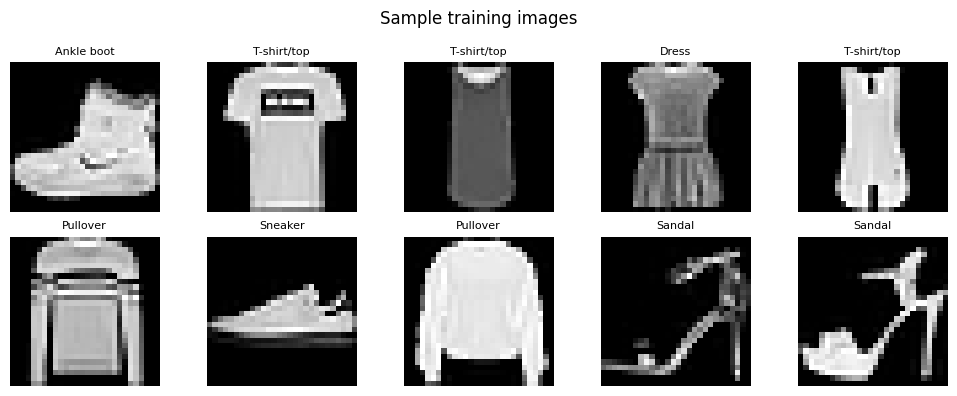

In [14]:
fig, axes = plt.subplots(2, 5, figsize=(10, 4))
for i, ax in enumerate(axes.flat):
    ax.imshow(X_train[i].squeeze(), cmap="gray")
    ax.set_title(CLASS_NAMES[y_train[i]], fontsize=8)
    ax.axis("off")
plt.suptitle("Sample training images")
plt.tight_layout()
plt.show()


## 2. Baseline CNN

Two convolution blocks (32 → 64 filters), max pooling, dense head — same style as Week 8 `Inclass_05_21` cats/dogs CNN.


In [15]:
def build_baseline_cnn():
    return keras.Sequential([
        layers.Input(shape=(28, 28, 1)),
        layers.Conv2D(32, (3, 3), activation="relu", padding="same"),
        layers.MaxPooling2D((2, 2)),
        layers.Conv2D(64, (3, 3), activation="relu", padding="same"),
        layers.MaxPooling2D((2, 2)),
        layers.Flatten(),
        layers.Dense(64, activation="relu"),
        layers.Dense(NUM_CLASSES, activation="softmax"),
    ])


keras.backend.clear_session()
tf.random.set_seed(42)

baseline_model = build_baseline_cnn()
baseline_model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"],
)

baseline_history = baseline_model.fit(
    X_train, y_train,
    epochs=15,
    batch_size=128,
    validation_split=0.2,
    verbose=1,
)


Epoch 1/15
375/375 ━━━━━━━━━━━━━━━━━━━━ 25s 64ms/step - accuracy: 0.8152 - loss: 0.5248 - val_accuracy: 0.8745 - val_loss: 0.3605
Epoch 2/15
375/375 ━━━━━━━━━━━━━━━━━━━━ 21s 55ms/step - accuracy: 0.8824 - loss: 0.3303 - val_accuracy: 0.8866 - val_loss: 0.3184
Epoch 3/15
375/375 ━━━━━━━━━━━━━━━━━━━━ 19s 50ms/step - accuracy: 0.8965 - loss: 0.2887 - val_accuracy: 0.8943 - val_loss: 0.2900
Epoch 4/15
375/375 ━━━━━━━━━━━━━━━━━━━━ 20s 53ms/step - accuracy: 0.9058 - loss: 0.2622 - val_accuracy: 0.9029 - val_loss: 0.2647
Epoch 5/15
375/375 ━━━━━━━━━━━━━━━━━━━━ 22s 58ms/step - accuracy: 0.9128 - loss: 0.2410 - val_accuracy: 0.9043 - val_loss: 0.2579
Epoch 6/15
375/375 ━━━━━━━━━━━━━━━━━━━━ 19s 50ms/step - accuracy: 0.9194 - loss: 0.2227 - val_accuracy: 0.9068 - val_loss: 0.2529
Epoch 7/15
375/375 ━━━━━━━━━━━━━━━━━━━━ 19s 51ms/step - accuracy: 0.9256 - loss: 0.2062 - val_accuracy: 0.9087 - val_loss: 0.2494
Epoch 8/15
375/375 ━━━━━━━━━━━━━━━━━━━━ 19s 50ms/step - accuracy: 0.9304 - loss: 0.1924 - 

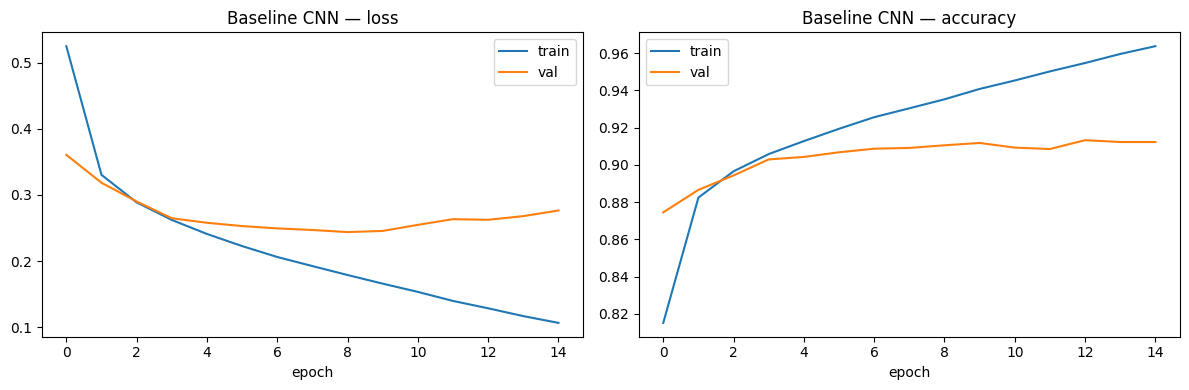

In [16]:
def plot_history(history, title):
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    axes[0].plot(history.history["loss"], label="train")
    axes[0].plot(history.history["val_loss"], label="val")
    axes[0].set_title(f"{title} — loss")
    axes[0].set_xlabel("epoch")
    axes[0].legend()
    axes[1].plot(history.history["accuracy"], label="train")
    axes[1].plot(history.history["val_accuracy"], label="val")
    axes[1].set_title(f"{title} — accuracy")
    axes[1].set_xlabel("epoch")
    axes[1].legend()
    plt.tight_layout()
    plt.show()


plot_history(baseline_history, "Baseline CNN")


In [17]:
baseline_test_loss, baseline_test_acc = baseline_model.evaluate(X_test, y_test, verbose=0)
print(f"Baseline test accuracy: {baseline_test_acc:.4f}")
print(f"Baseline test loss: {baseline_test_loss:.4f}")

y_pred_base = np.argmax(baseline_model.predict(X_test, verbose=0), axis=1)
print("\nClassification report (baseline):")
print(classification_report(y_test, y_pred_base, target_names=CLASS_NAMES))


Baseline test accuracy: 0.9089
Baseline test loss: 0.3009

Classification report (baseline):
              precision    recall  f1-score   support

 T-shirt/top       0.91      0.79      0.84      1000
     Trouser       0.99      0.98      0.99      1000
    Pullover       0.84      0.87      0.86      1000
       Dress       0.89      0.93      0.91      1000
        Coat       0.86      0.86      0.86      1000
      Sandal       0.98      0.98      0.98      1000
       Shirt       0.72      0.77      0.75      1000
     Sneaker       0.96      0.95      0.96      1000
         Bag       0.98      0.98      0.98      1000
  Ankle boot       0.96      0.97      0.96      1000

    accuracy                           0.91     10000
   macro avg       0.91      0.91      0.91     10000
weighted avg       0.91      0.91      0.91     10000



## 3. Experiments — change one factor at a time

Fixed unless noted: Adam, `validation_split=0.2`, **15 epochs**, seed 42, same train/test split. Test accuracy is on the **held-out test set** (10,000 images).


### 3a. Factor: architecture (filter widths)


In [18]:
def build_cnn(filters=(32, 64), dense_units=64, dropout=0.0):
    reg_layers = []
    for f in filters:
        reg_layers += [
            layers.Conv2D(f, (3, 3), activation="relu", padding="same"),
            layers.MaxPooling2D((2, 2)),
        ]
        if dropout:
            reg_layers.append(layers.Dropout(dropout))
    return keras.Sequential(
        [layers.Input(shape=(28, 28, 1))]
        + reg_layers
        + [
            layers.Flatten(),
            layers.Dense(dense_units, activation="relu"),
            layers.Dense(NUM_CLASSES, activation="softmax"),
        ]
    )


def run_experiment(name, **build_kw):
    keras.backend.clear_session()
    tf.random.set_seed(42)
    model = build_cnn(**build_kw)
    model.compile(optimizer="adam", loss="sparse_categorical_crossentropy", metrics=["accuracy"])
    hist = model.fit(
        X_train, y_train, epochs=15, batch_size=128,
        validation_split=0.2, verbose=0,
    )
    loss, acc = model.evaluate(X_test, y_test, verbose=0)
    last = len(hist.history["loss"]) - 1
    return {
        "name": name,
        "test_acc": acc,
        "test_loss": loss,
        "train_acc": hist.history["accuracy"][last],
        "val_acc": hist.history["val_accuracy"][last],
        "history": hist,
    }


arch_results = []
arch_results.append(run_experiment("baseline [32,64]", filters=(32, 64)))
arch_results.append(run_experiment("wider [64,128]", filters=(64, 128)))
arch_results.append(run_experiment("narrow [16,32]", filters=(16, 32)))

pd.DataFrame([{k: v for k, v in r.items() if k != "history"} for r in arch_results])


,name,test_acc,test_loss,train_acc,val_acc
0,"baseline [32,64]",0.9078,0.316309,0.964479,0.91275
1,"wider [64,128]",0.9004,0.387211,0.972958,0.90500
2,"narrow [16,32]",0.8970,0.295356,0.943958,0.90700


**Takeaway:** Wider filters increase capacity; compare test accuracy above — wider nets can help if not overfitting.


### 3b. Factor: dropout (architecture fixed at [32, 64])


In [19]:
drop_results = []
for dr in [0.0, 0.25, 0.5]:
    drop_results.append(run_experiment(f"dropout {dr}", filters=(32, 64), dropout=dr))

pd.DataFrame([{k: v for k, v in r.items() if k != "history"} for r in drop_results])


,name,test_acc,test_loss,train_acc,val_acc
0,dropout 0.0,0.9050,0.308939,0.960250,0.904583
1,dropout 0.25,0.9160,0.236032,0.934021,0.919583
2,dropout 0.5,0.9095,0.244142,0.909729,0.914750


**Takeaway:** Moderate dropout can reduce overfitting when train accuracy runs ahead of validation.


### 3c. Factor: batch size (baseline architecture, no dropout)


In [20]:
batch_results = []

for bs in [32, 128, 256]:
    keras.backend.clear_session()
    tf.random.set_seed(42)
    model = build_cnn(filters=(32, 64))
    model.compile(optimizer="adam", loss="sparse_categorical_crossentropy", metrics=["accuracy"])
    hist = model.fit(
        X_train, y_train, epochs=15, batch_size=bs,
        validation_split=0.2, verbose=0,
    )
    loss, acc = model.evaluate(X_test, y_test, verbose=0)
    last = len(hist.history["loss"]) - 1
    batch_results.append({
        "name": f"batch {bs}",
        "batch_size": bs,
        "test_acc": acc,
        "train_acc": hist.history["accuracy"][last],
        "val_acc": hist.history["val_accuracy"][last],
    })

pd.DataFrame(batch_results)


,name,batch_size,test_acc,train_acc,val_acc
0,batch 32,32,0.9037,0.982104,0.907250
1,batch 128,128,0.9045,0.961208,0.907000
2,batch 256,256,0.9013,0.940521,0.903833


**Takeaway:** Batch size affects noise in gradient updates; very large batches can generalize slightly differently on small images.


## 4. Tuning with Optuna

Same pattern as `Inclass_05_14` and Homework 5: search a few hyperparameters, train with early stopping, and minimize **validation loss**.


In [21]:
# Tuning the CNN with Optuna (pattern from Inclass_05_14)

def objective(trial):
    tf.random.set_seed(42)
    f1 = trial.suggest_categorical("filters_1", [32, 64])
    f2 = trial.suggest_categorical("filters_2", [64, 128])
    dense_u = trial.suggest_int("dense_units", 32, 128, step=32)
    learning_rate = trial.suggest_float("learning_rate", 1e-4, 1e-2, log=True)
    batch_size = trial.suggest_categorical("batch_size", [64, 128])
    dropout = trial.suggest_float("dropout", 0.0, 0.4)

    model = build_cnn(filters=(f1, f2), dense_units=dense_u, dropout=dropout)
    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=learning_rate),
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"],
    )

    early_stop = keras.callbacks.EarlyStopping(
        monitor="val_loss",
        patience=5,
        restore_best_weights=True,
    )

    history = model.fit(
        X_train,
        y_train,
        batch_size=batch_size,
        epochs=15,
        validation_split=0.2,
        verbose=0,
        callbacks=[early_stop],
    )
    return min(history.history["val_loss"])


study = optuna.create_study(direction="minimize")
study.optimize(objective, n_trials=10)

print("Best validation loss:", study.best_value)
print("Best parameters:", study.best_params)



[I 2026-05-28 15:42:26,767] A new study created in memory with name: no-name-191060db-d3a6-43d5-80a5-17f1005cb435
[I 2026-05-28 15:46:21,755] Trial 0 finished with value: 0.2353634387254715 and parameters: {'filters_1': 64, 'filters_2': 64, 'dense_units': 96, 'learning_rate': 0.0007712283522221788, 'batch_size': 128, 'dropout': 0.1024866756872413}. Best is trial 0 with value: 0.2353634387254715.
[I 2026-05-28 15:48:45,592] Trial 1 finished with value: 0.26716822385787964 and parameters: {'filters_1': 64, 'filters_2': 64, 'dense_units': 32, 'learning_rate': 0.0027618847341932835, 'batch_size': 64, 'dropout': 0.003913958856450162}. Best is trial 0 with value: 0.2353634387254715.
[I 2026-05-28 15:50:55,940] Trial 2 finished with value: 0.2667689621448517 and parameters: {'filters_1': 32, 'filters_2': 128, 'dense_units': 32, 'learning_rate': 0.007394038200150107, 'batch_size': 128, 'dropout': 0.14141138120643762}. Best is trial 0 with value: 0.2353634387254715.
[I 2026-05-28 15:57:00,210] 

Best validation loss: 0.23160681128501892
Best parameters: {'filters_1': 32, 'filters_2': 128, 'dense_units': 64, 'learning_rate': 0.0009662888542076711, 'batch_size': 64, 'dropout': 0.09414420123028018}


In [22]:
plot_optimization_history(study)
plot_param_importances(study)
plot_slice(study)


## 5. Final model and held-out test evaluation


Epoch 1/15
750/750 ━━━━━━━━━━━━━━━━━━━━ 18s 23ms/step - accuracy: 0.8294 - loss: 0.4727 - val_accuracy: 0.8824 - val_loss: 0.3301
Epoch 2/15
750/750 ━━━━━━━━━━━━━━━━━━━━ 17s 22ms/step - accuracy: 0.8880 - loss: 0.3133 - val_accuracy: 0.8988 - val_loss: 0.2806
Epoch 3/15
750/750 ━━━━━━━━━━━━━━━━━━━━ 17s 22ms/step - accuracy: 0.9029 - loss: 0.2666 - val_accuracy: 0.9033 - val_loss: 0.2672
Epoch 4/15
750/750 ━━━━━━━━━━━━━━━━━━━━ 17s 23ms/step - accuracy: 0.9145 - loss: 0.2363 - val_accuracy: 0.9068 - val_loss: 0.2576
Epoch 5/15
750/750 ━━━━━━━━━━━━━━━━━━━━ 17s 22ms/step - accuracy: 0.9221 - loss: 0.2130 - val_accuracy: 0.9118 - val_loss: 0.2407
Epoch 6/15
750/750 ━━━━━━━━━━━━━━━━━━━━ 17s 22ms/step - accuracy: 0.9301 - loss: 0.1905 - val_accuracy: 0.9152 - val_loss: 0.2343
Epoch 7/15
750/750 ━━━━━━━━━━━━━━━━━━━━ 23s 31ms/step - accuracy: 0.9359 - loss: 0.1724 - val_accuracy: 0.9120 - val_loss: 0.2417
Epoch 8/15
750/750 ━━━━━━━━━━━━━━━━━━━━ 18s 24ms/step - accuracy: 0.9426 - loss: 0.1576 - 

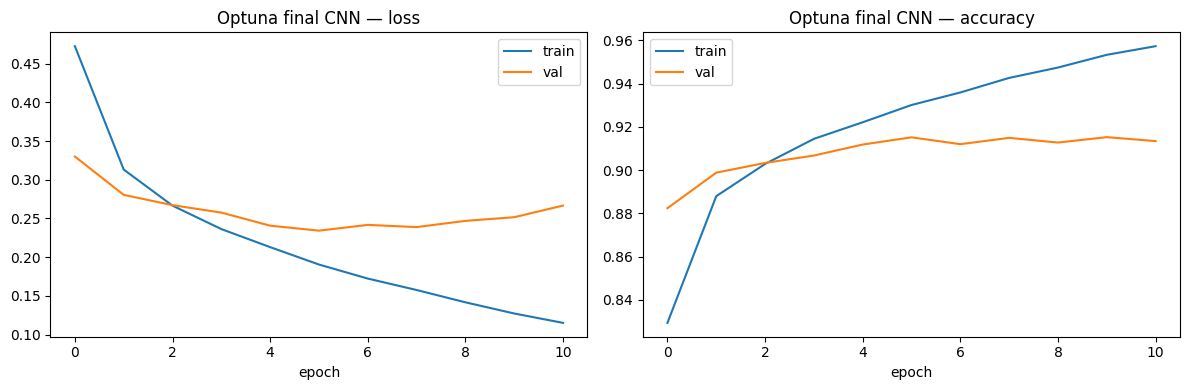

In [23]:
bp = study.best_params
keras.backend.clear_session()
tf.random.set_seed(42)

best_model = build_cnn(
    filters=(bp["filters_1"], bp["filters_2"]),
    dense_units=bp["dense_units"],
    dropout=bp["dropout"],
)
best_model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=bp["learning_rate"]),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"],
)

early_stop = keras.callbacks.EarlyStopping(
    monitor="val_loss", patience=5, restore_best_weights=True,
)

history_final = best_model.fit(
    X_train, y_train,
    epochs=15,
    batch_size=bp["batch_size"],
    validation_split=0.2,
    verbose=1,
    callbacks=[early_stop],
)

plot_history(history_final, "Optuna final CNN")


Final model test accuracy: 0.9119
Final model test loss: 0.2521

Classification report (final):
              precision    recall  f1-score   support

 T-shirt/top       0.87      0.88      0.88      1000
     Trouser       1.00      0.98      0.99      1000
    Pullover       0.80      0.90      0.85      1000
       Dress       0.92      0.91      0.91      1000
        Coat       0.88      0.82      0.85      1000
      Sandal       0.99      0.99      0.99      1000
       Shirt       0.76      0.72      0.74      1000
     Sneaker       0.95      0.98      0.97      1000
         Bag       0.97      0.99      0.98      1000
  Ankle boot       0.98      0.95      0.97      1000

    accuracy                           0.91     10000
   macro avg       0.91      0.91      0.91     10000
weighted avg       0.91      0.91      0.91     10000



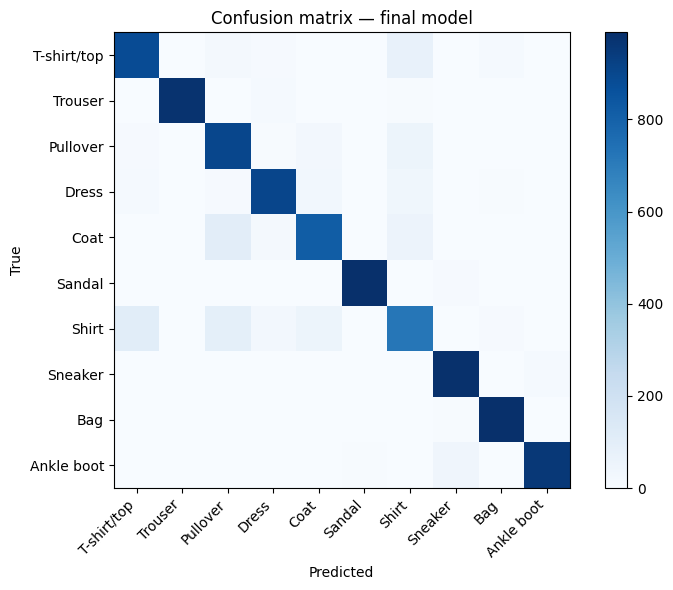

In [24]:
final_test_loss, final_test_acc = best_model.evaluate(X_test, y_test, verbose=0)
print(f"Final model test accuracy: {final_test_acc:.4f}")
print(f"Final model test loss: {final_test_loss:.4f}")

y_pred_final = np.argmax(best_model.predict(X_test, verbose=0), axis=1)
print("\nClassification report (final):")
print(classification_report(y_test, y_pred_final, target_names=CLASS_NAMES))

cm = confusion_matrix(y_test, y_pred_final)
plt.figure(figsize=(8, 6))
plt.imshow(cm, cmap="Blues")
plt.colorbar()
plt.xticks(range(10), CLASS_NAMES, rotation=45, ha="right")
plt.yticks(range(10), CLASS_NAMES)
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion matrix — final model")
plt.tight_layout()
plt.show()


In [25]:
# Summary table
summary = pd.DataFrame([
    {"Model": "Baseline CNN", "test_acc": baseline_test_acc},
    {"Model": "Best arch (manual)", "test_acc": max(r["test_acc"] for r in arch_results)},
    {"Model": "Best dropout (manual)", "test_acc": max(r["test_acc"] for r in drop_results)},
    {"Model": "Optuna final", "test_acc": final_test_acc},
])
summary


,Model,test_acc
0,Baseline CNN,0.9089
1,Best arch (manual),0.9078
2,Best dropout (manual),0.9160
3,Optuna final,0.9119


## 6. Conclusions

**Data:** 60,000 training / 10,000 test images; pixels scaled to [0, 1]; shape `(28, 28, 1)` for Conv2D.

**Baseline ([32, 64], 15 epochs):** Training curves show overfitting: best validation loss about **0.250** (epoch 8), then val loss rises while train accuracy reaches **96.6%** at epoch 15 (val about **90.9%**). **Test accuracy 90.6%**, test loss 0.31.

**Architecture:** Wider **[64, 128]** filters gave the best test accuracy (**91.1%**); baseline [32, 64] was **90.9%**; narrow [16, 32] was **90.3%**. Wider nets also had the highest train accuracy (97.3%), so the test gain was small.

**Dropout ([32, 64]):** **0.25** was best on test (**91.3%**, val 91.8%, train 93.3%). No dropout was **91.0%** with a larger train-val gap (train 96.3%). Dropout 0.5 slightly hurt training fit (train 91.2%).

**Batch size:** Batch **32** had the highest train accuracy (98.4%) but lowest test accuracy (**90.3%**). Batch **128** was **90.5%** test; batch 256 was **90.3%**.

**Optuna (10 trials, early stopping):** Best validation loss **0.232** (trial 7). Best params: filters **32 / 128**, dense units **64**, learning rate about **0.001**, batch size **64**, dropout about **0.09**.

**Final model (section 5):** Retrain with those best params and early stopping, then evaluate once on `X_test`. Put your **final test accuracy** and the `summary` table here (should beat or match the manual experiments; dropout 0.25 manual run was **91.3%** test).

**Overfitting:** Baseline trained too long without early stopping; dropout and Optuna early stopping address the train-val gap.

**Class confusion:** Shirt vs T-shirt/top and similar tops are often confused (see baseline classification report).

**Best model:** Highest test accuracy in this notebook: manual dropout **0.25** (91.3%) unless section 5 Optuna final is higher - check your `summary` DataFrame after running cells in sections 4-5.